# Logistic Regression

In this assignment, you will implement logistic regression and apply it to three different datasets.


# Outline
- [ 1 - Setup & Packages ](#1)
- [ 2 - Logistic Regression](#2)
  - [ 2.1 Problem Statement](#2.1)
  - [ 2.2 Loading and visualizing the data](#2.2)
  - [ 2.3 Sigmoid function](#2.3)
    - [ Exercise 1](#ex-01)
  - [ 2.4 Cost function for logistic regression](#2.4)
    - [ Exercise 2](#ex-02)
  - [ 2.5 Gradient for logistic regression](#2.5)
    - [ Exercise 3](#ex-03)
  - [ 2.6 Learning parameters using gradient descent ](#2.6)
  - [ 2.7 Plotting the decision boundary](#2.7)
  - [ 2.8 Evaluating logistic regression](#2.8)
     - [ Exercise 4](#ex-04)
- [ 3 - Regularized Logistic Regression](#3)
  - [ 3.1 Problem Statement](#3.1)
  - [ 3.2 Loading and visualizing the data](#3.2)
  - [ 3.3 Feature mapping](#3.3)
  - [ 3.4 Cost function for regularized logistic regression](#3.4)
   - [ Exercise 5](#ex-05)
  - [ 3.5 Gradient for regularized logistic regression](#3.5)
    - [ Exercise 6](#ex-06)
  - [ 3.6 Learning parameters using gradient descent](#3.6)
  - [ 3.7 Plotting the decision boundary](#3.7)
  - [ 3.8 Evaluating regularized logistic regression model](#3.8)
  - [ 4 - Logistic regression using Scikit-Learn ](#4)
    - [Exercise 7](#ex07)
  - [ 5 - Softmax Regression](#5)
    - [ 5.1 Problem Statement](#5.1)
    - [ 5.2 Loading and visualizing the data](#5.2)
      - [ Exercise 8](#ex-08)
    - [ 5.3 Softmax function](#5.3)
      - [ Exercise 9](#ex-09)
    - [ 5.4 Cost function for softmax regression](#2.4)
      - [ Exercise 10](#ex-10)
    - [ 5.5 Gradient for softmax regression](#2.5)
      - [ Exercise 11](#ex-11)
    - [ 5.6 Learning parameters using gradient descent ](#5.6)
    - [ 5.7 Evaluating softmax regression](#5.7)
       - [ Exercise 12](#ex-12)


<a name="1"></a>
# 1 -  Setup and Packages

Before starting, make sure to mount your Google Drive and navigate to the correct directory where this notebook is located. This ensures you can access the dataset and utility libraries.

**Step 1: Mount Google Drive**

Run the following code to mount your Google Drive:



In [84]:
# from google.colab import drive
# drive.mount('/content/drive')

**Step 2: Navigate to the Notebook's Directory**

Change to the directory where this notebook is located. This ensures you can access the dataset and utility files:

In [85]:
# cd "/content/drive/MyDrive/Colab Notebooks/Machine Learning 1/Tests/lab3/"

**Step 3: Import Required Packages**

Next, let's run the cell below to import all the packages that you will need during this assignment.

- [numpy](www.numpy.org) is the fundamental package for scientific computing with Python.
- [matplotlib](http://matplotlib.org) is a famous library to plot graphs in Python.
-  ``utils.py`` contains helper functions for this assignment. You do not need to modify code in this file.

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math

<a name="2"></a>
# 2 - Logistic Regression

In this part of the assignment, you will build a logistic regression model to predict whether a student gets admitted into a university.

<a name="2.1"></a>
## 2.1 Problem Statement

Suppose that you are the administrator of a university department and you want to determine each applicant’s chance of admission based on their results on two exams.
* You have historical data from previous applicants that you can use as a training set for logistic regression.
* For each training example, you have the applicant’s scores on two exams and the admissions decision.
* Your task is to build a classification model that estimates an applicant’s probability of admission based on the scores from those two exams.

<a name="2.2"></a>
## 2.2 Loading and visualizing the data

You will start by loading the dataset for this task.
- The `load_dataset()` function shown below loads the data into variables `X_train` and `y_train`
  - `X_train` contains exam scores on two exams for a student
  - `y_train` is the admission decision
      - `y_train = 1` if the student was admitted
      - `y_train = 0` if the student was not admitted
  - Both `X_train` and `y_train` are numpy arrays.


In [87]:
def load_data(filename):
    data = np.loadtxt(filename, delimiter=',')
    X = data[:,:2]
    y = data[:,2]
    return X, y

In [88]:
# load dataset
X_train, y_train = load_data("data/ex2data1.txt")

## **View the variables**
Let's get more familiar with your dataset.  
- A good place to start is to just print out each variable and see what it contains.

The code below prints the first five values of `X_train` and the type of the variable.

In [89]:
print("Five elements in X_train are:\n", X_train[5:10])
print("Type of X_train:",type(X_train))

Five elements in X_train are:
 [[45.08327748 56.31637178]
 [61.10666454 96.51142588]
 [75.02474557 46.55401354]
 [76.0987867  87.42056972]
 [84.43281996 43.53339331]]
Type of X_train: <class 'numpy.ndarray'>


Now print the first five values of `y_train`

In [90]:
print("Five elements in y_train are:\n", y_train[5:10])
print("Type of y_train:",type(y_train))

Five elements in y_train are:
 [0. 1. 1. 1. 1.]
Type of y_train: <class 'numpy.ndarray'>


## **Check the dimensions of your variables**

Another useful way to get familiar with your data is to view its dimensions. Let's print the shape of `X_train` and `y_train` and see how many training examples we have in our dataset.

In [91]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (100, 2)
The shape of y_train is: (100,)
We have m = 100 training examples


## **Visualize your data**

Before starting to implement any learning algorithm, it is always good to visualize the data if possible.
- The code below displays the data on a 2D plot (as shown below), where the axes are the two exam scores, and the positive and negative examples are shown with different markers.
- We use a helper function ``plot_data`` file to generate this plot.

In [92]:
def plot_data(X, y, pos_label="y=1", neg_label="y=0"):
    positive = y == 1
    negative = y == 0

    # Plot examples
    plt.plot(X[positive, 0], X[positive, 1], 'b*', label=pos_label)
    plt.plot(X[negative, 0], X[negative, 1], 'ro', label=neg_label)

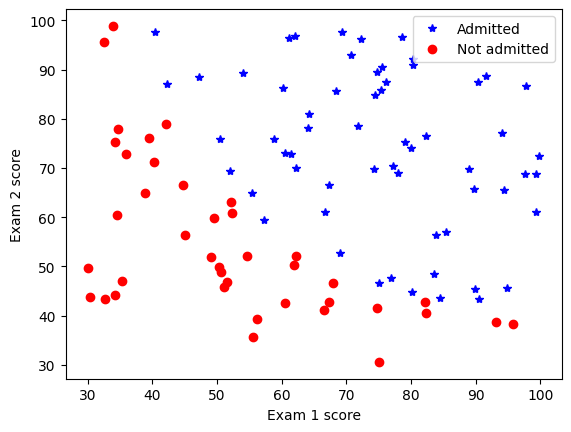

In [93]:
# Plot examples
plot_data(X_train, y_train, pos_label="Admitted", neg_label="Not admitted")

# Set the y-axis label
plt.ylabel('Exam 2 score')
# Set the x-axis label
plt.xlabel('Exam 1 score')
plt.legend(loc="upper right")
plt.show()

Your goal is to build a logistic regression model to separate this data.
- With this model, you can then predict if a new student will be admitted based on their scores on the two exams.

<a name="2.3"></a>
## 2.3  Sigmoid function

Recall that for logistic regression, the model is represented as

$$ f_{\mathbf{w},b}(x) = g(\mathbf{w}\cdot \mathbf{x} + b)$$
where function $g$ is the sigmoid function. The sigmoid function is defined as:

$$g(z) = \frac{1}{1+e^{-z}}$$

Let's implement the sigmoid function first, so it can be used by the rest of this assignment.

<a name='ex-01'></a>
### Exercise 1
Complete  the `sigmoid` function to calculate

$$g(z) = \frac{1}{1+e^{-z}}$$

Note that
- `z` is not always a single number, but can also be an array of numbers.
- If the input is an array of numbers, we'd like to apply the sigmoid function to each value in the input array.


In [94]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

When you are finished, try testing a few values by calling `sigmoid(x)` in the cell below.
- For large positive values of x, the sigmoid should be close to 1, while for large negative values, the sigmoid should be close to 0.
- Evaluating `sigmoid(0)` should give you exactly 0.5.


In [95]:
print ("sigmoid(0) = " + str(sigmoid(0)))

sigmoid(0) = 0.5


**Expected Output**:
<table>
  <tr>
    <td> <b>sigmoid(0)<b></td>
    <td> 0.5 </td>
  </tr>
</table>
    
- As mentioned before, your code should also work with vectors and matrices. For a matrix, your function should perform the sigmoid function on every element.

In [96]:
print ("sigmoid([ -1, 0, 1, 2]) = " + str(sigmoid(np.array([-1, 0, 1, 2]))))

# UNIT TESTS
from public_tests import *
sigmoid_test(sigmoid)

sigmoid([ -1, 0, 1, 2]) = [0.26894142 0.5        0.73105858 0.88079708]
All tests passed!


**Expected Output**:
<table>
  <tr>
    <td><b>sigmoid([-1, 0, 1, 2])<b></td>
    <td>[0.26894142        0.5           0.73105858        0.88079708]</td>
  </tr>    
  
</table>

<a name="2.4"></a>
## 2.4 Cost function for logistic regression

In this section, you will implement the cost function for logistic regression.

<a name='ex-02'></a>
### Exercise 2

Complete the `compute_cost` function using the equations below.

Recall that for logistic regression, the cost function is of the form

$$ J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

where
* $m$ is the number of training examples in the dataset


* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point, which is -

    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$
    
    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$, which is the actual label

*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x^{(i)}} + b)$ where function $g$ is the sigmoid function.
    * It might be helpful to first calculate an intermediate variable

    $$ z_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x^{(i)}} + b = w_0 x^{(i)}_0 + ... + w_\{n-1\} x^{(i)}_\{n-1\} + b$$
    
    where $n$ is the number of features, before calculating $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(z_{\mathbf{w},b}(\mathbf{x}^{(i)}))$

Note:
* As you are doing this, remember that the variables `X_train` and `y_train` are not scalar values but matrices of shape ($m, n$) and ($𝑚$,1) respectively, where  $𝑛$ is the number of features and $𝑚$ is the number of training examples.
* You can use the sigmoid function that you implemented above for this part.


In [97]:
def compute_cost(X, y, w, b, lambda_=1):
    m = X.shape[0]
    z = X @ w + b
    h = 1/(1+np.exp(-z))
    cost = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
    return cost

Run the cells below to check your implementation of the `compute_cost` function with two different initializations of the parameters $w$

In [98]:
m, n = X_train.shape

# Compute and display cost with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_cost(X_train, y_train, initial_w, initial_b)
print('Cost at initial w (zeros): {:.3f}'.format(cost))

Cost at initial w (zeros): 0.693


**Expected Output**:
<table>
  <tr>
    <td> <b>Cost at initial w (zeros)<b></td>
    <td> 0.693 </td>
  </tr>
</table>

In [99]:
# Compute and display cost with non-zero w
test_w = np.array([0.2, 0.2])
test_b = -24.
cost = compute_cost(X_train, y_train, test_w, test_b)

print('Cost at test w,b: {:.3f}'.format(cost))


# UNIT TESTS
compute_cost_test(compute_cost)


Cost at test w,b: 0.218
All tests passed!


**Expected Output**:
<table>
  <tr>
    <td> <b>Cost at test w,b<b></td>
    <td> 0.218 </td>
  </tr>
</table>

<a name="2.5"></a>
## 2.5 Gradient for logistic regression

In this section, you will implement the gradient for logistic regression.

Recall that the gradient descent algorithm is:

$$\begin{align*}& \text{repeat until convergence:} \; \lbrace \newline \; & b := b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \newline       \; & w_j := w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j := 0..n-1}\newline & \rbrace\end{align*}$$

where, parameters $b$, $w_j$ are all updated simultaniously


<a name='ex-03'></a>
### Exercise 3

Complete the `compute_gradient` function to compute $\frac{\partial J(\mathbf{w},b)}{\partial w}$, $\frac{\partial J(\mathbf{w},b)}{\partial b}$ from equations (2) and (3) below.

$$
\frac{\partial J(\mathbf{w},b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)}) \tag{2}
$$
$$
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})x_{j}^{(i)} \tag{3}
$$
* m is the number of training examples in the dataset

    
*  $f_{\mathbf{w},b}(x^{(i)})$ is the model's prediction, while $y^{(i)}$ is the actual label


- **Note**: While this gradient looks identical to the linear regression gradient, the formula is actually different because linear and logistic regression have different definitions of $f_{\mathbf{w},b}(x)$.

As before, you can use the sigmoid function that you implemented above.

In [100]:
def compute_gradient(X, y, w, b, lambda_=None):
    """
    Computes the gradient for logistic regression

    Args:
      X : (ndarray Shape (m,n)) variable such as house size
      y : (array_like Shape (m,1)) actual value
      w : (array_like Shape (n,1)) values of parameters of the model
      b : (scalar)                 value of parameter of the model
      lambda_: unused placeholder.
    Returns
      dj_dw: (array_like Shape (n,1)) The gradient of the cost w.r.t. the parameters w.
      dj_db: (scalar)                The gradient of the cost w.r.t. the parameter b.
    """
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.

    ### START CODE HERE ###

    z = np.dot(X,w) + b
    g = sigmoid(z)
    error = g - y
    dj_db = np.mean(error, axis=0)
    dj_dw = np.dot(error,X) / m

    ### END CODE HERE ###


    return dj_db, dj_dw

Run the cells below to check your implementation of the `compute_gradient` function with two different initializations of the parameters $w$

In [101]:
# Compute and display gradient with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.

dj_db, dj_dw = compute_gradient(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w (zeros):{dj_db}' )
print(f'dj_dw at initial w (zeros):{dj_dw.tolist()}' )

dj_db at initial w (zeros):-0.1
dj_dw at initial w (zeros):[-12.009216589291151, -11.262842205513593]


**Expected Output**:
<table>
  <tr>
    <td> <b>dj_db at initial w (zeros)<b></td>
    <td> -0.1 </td>
  </tr>
  <tr>
    <td> <b>ddj_dw at initial w (zeros):<b></td>
    <td> [-12.00921658929115, -11.262842205513591] </td>
  </tr>
</table>

In [102]:
# Compute and display cost and gradient with non-zero w
test_w = np.array([ 0.2, -0.5])
test_b = -24
dj_db, dj_dw  = compute_gradient(X_train, y_train, test_w, test_b)

print('dj_db at test_w:', dj_db)
print('dj_dw at test_w:', dj_dw.tolist())

# UNIT TESTS
compute_gradient_test(compute_gradient)


dj_db at test_w: -0.5999999999991071
dj_dw at test_w: [-44.83135361787378, -44.37384124953978]
All tests passed!


**Expected Output**:
<table>
  <tr>
    <td> <b>dj_db at initial w (zeros)<b></td>
    <td> -0.5999999999991071 </td>
  </tr>
  <tr>
    <td> <b>ddj_dw at initial w (zeros):<b></td>
    <td>  [-44.8313536178737957, -44.37384124953978] </td>
  </tr>
</table>

<a name="2.6"></a>
### 2.6 Learning parameters using gradient descent

Similar to the previous assignment, you will now find the optimal parameters of a logistic regression model by using gradient descent.
- You don't need to implement anything for this part. Simply run the cells below.

- A good way to verify that gradient descent is working correctly is to look
at the value of $J(\mathbf{w},b)$ and check that it is decreasing with each step.

- Assuming you have implemented the gradient and computed the cost correctly, your value of $J(\mathbf{w},b)$ should never increase, and should converge to a steady value by the end of the algorithm.

In [103]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_):
    """
    Performs batch gradient descent to learn theta. Updates theta by taking
    num_iters gradient steps with learning rate alpha

    Args:
      X :    (array_like Shape (m, n)
      y :    (array_like Shape (m,))
      w_in : (array_like Shape (n,))  Initial values of parameters of the model
      b_in : (scalar)                 Initial value of parameter of the model
      cost_function:                  function to compute cost
      alpha : (float)                 Learning rate
      num_iters : (int)               number of iterations to run gradient descent
      lambda_ (scalar, float)         regularization constant

    Returns:
      w : (array_like Shape (n,)) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """

    # number of training examples
    m = len(X)

    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w_history = []

    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in, lambda_)

        # Update Parameters using w, b, alpha and gradient
        w_in = w_in - alpha * dj_dw
        b_in = b_in - alpha * dj_db

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion
            cost =  cost_function(X, y, w_in, b_in, lambda_)
            J_history.append(cost)


        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

    return w_in, b_in, J_history, w_history #return w and J,w history for graphing

Now let's run the gradient descent algorithm above to learn the parameters for our dataset.

**Note**

The code block below takes a couple of minutes to run, especially with a non-vectorized version. You can reduce the `iterations` to test your implementation and iterate faster. If you have time, try running 100,000 iterations for better results.

In [104]:
initial_w = np.array([-0.00082978,  0.00220324])
initial_b = -8

# Some gradient descent settings
iterations = 10000
alpha = 0.001

w,b, J_history,_ = gradient_descent(X_train ,y_train, initial_w, initial_b,
                                   compute_cost, compute_gradient, alpha, iterations, 0)
print(f"b,w found by gradient descent: {b:0.2f},{w} ")

Iteration    0: Cost     0.96   
Iteration 1000: Cost     0.31   
Iteration 2000: Cost     0.30   
Iteration 3000: Cost     0.30   
Iteration 4000: Cost     0.30   
Iteration 5000: Cost     0.30   
Iteration 6000: Cost     0.30   
Iteration 7000: Cost     0.30   
Iteration 8000: Cost     0.30   
Iteration 9000: Cost     0.30   
Iteration 9999: Cost     0.30   
b,w found by gradient descent: -8.19,[0.07125355 0.06482888] 


<details>
<summary>
    <b>Expected Output: Cost     0.30, (Click to see details):</b>
</summary>

    # With the following settings
    np.random.seed(1)
    intial_w = np.array([-0.00082978,  0.00220324])
    initial_b = -8
    iterations = 10000
    alpha = 0.001
    #

```
  
```

<a name="2.7"></a>
## 2.7 Plotting the decision boundary

We will now use the final parameters from gradient descent to plot the linear fit. If you implemented the previous parts correctly, you should see the following plot:   

We will use a helper function `plot_decision_boundary`  to create this plot.

In [105]:
def plot_decision_boundary(w, b, X, y):
    # Credit to dibgerge on Github for this plotting code

    plot_data(X[:, 0:2], y)

    if X.shape[1] <= 2:
        plot_x = np.array([min(X[:, 0]), max(X[:, 0])])
        plot_y = (-1. / w[1]) * (w[0] * plot_x + b)

        plt.plot(plot_x, plot_y, c="b")

    else:
        u = np.linspace(-1, 1.5, 50)
        v = np.linspace(-1, 1.5, 50)

        z = np.zeros((len(u), len(v)))

        # Evaluate z = theta*x over the grid
        for i in range(len(u)):
            for j in range(len(v)):
                z[i,j] = sigmoid(np.dot(map_feature(u[i], v[j]), w) + b)

        # important to transpose z before calling contour
        z = z.T

        # Plot z = 0
        plt.contour(u,v,z, levels = [0.5], colors="g")

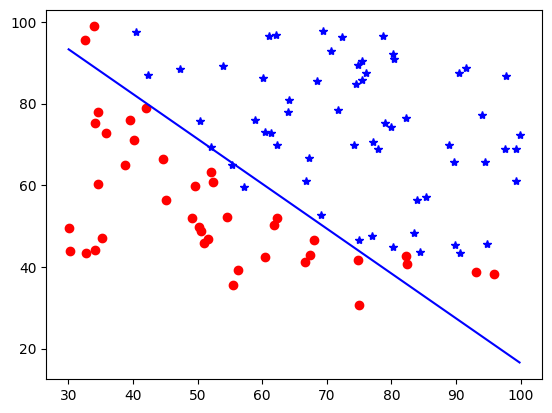

In [106]:
plot_decision_boundary(w, b, X_train, y_train) # **Non-linear boundary case!!**

<a name="2.8"></a>
## 2.8 Evaluating logistic regression

We can evaluate the quality of the parameters we have found by seeing how well the learned model predicts on our training set.

You will implement the `predict` function below to do this.


<a name='ex-04'></a>
### Exercise 4

Complete the `predict` function to produce `1` or `0` predictions given a dataset and a learned parameter vector $w$ and $b$.
- First you need to compute the prediction from the model $f(x^{(i)}) = g(w \cdot x^{(i)})$ for every example
    - You've implemented this before in the parts above
- We interpret the output of the model ($f(x^{(i)})$) as the probability that $y^{(i)}=1$ given $x^{(i)}$ and parameterized by $w$.
- Therefore, to get a final prediction ($y^{(i)}=0$ or $y^{(i)}=1$) from the logistic regression model, you can use the following heuristic -

  if $f(x^{(i)}) >= 0.5$, predict $y^{(i)}=1$
  
  if $f(x^{(i)}) < 0.5$, predict $y^{(i)}=0$

In [107]:
def predict(X, w, b):
    probs = 1/(1+np.exp(-(X @ w + b)))
    return (probs >= 0.5).astype(int)

Once you have completed the function `predict`, let's run the code below to report the training accuracy of your classifier by computing the percentage of examples it got correct.

In [108]:
# Test your predict code
np.random.seed(1)
tmp_w = np.random.randn(2)
tmp_b = 0.3
tmp_X = np.random.randn(4, 2) - 0.5

tmp_p = predict(tmp_X, tmp_w, tmp_b)
print(f'Output of predict: shape {tmp_p.shape}, value {tmp_p}')

# UNIT TESTS
predict_test(predict)

Output of predict: shape (4,), value [0 1 1 1]
All tests passed!


**Expected output**

<table>
  <tr>
    <td> <b>Output of predict: shape (4,),value [0. 1. 1. 1.]<b></td>
  </tr>
</table>

Now let's use this to compute the accuracy on the training set

In [109]:
#Compute accuracy on our training set
p = predict(X_train, w,b)
print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 92.000000


<table>
  <tr>
    <td> <b>Train Accuracy (approx):<b></td>
    <td> 92.00 </td>
  </tr>
</table>

<a name="3"></a>
## 3 - Regularized Logistic Regression

In this part of the assignment, you will implement regularized logistic regression to predict whether microchips from a fabrication plant passes quality assurance (QA). During QA, each microchip goes through various tests to ensure it is functioning correctly.

<a name="3.1"></a>
## 3.1 Problem Statement

Suppose you are the product manager of the factory and you have the test results for some microchips on two different tests.
- From these two tests, you would like to determine whether the microchips should be accepted or rejected.
- To help you make the decision, you have a dataset of test results on past microchips, from which you can build a logistic regression model.

<a name="3.2"></a>
## 3.2 Loading and visualizing the data

Similar to previous parts of this assignment, let's start by loading the dataset for this task and visualizing it.

- The `load_dataset()` function shown below loads the data into variables `X_train` and `y_train`
  - `X_train` contains the test results for the microchips from two tests
  - `y_train` contains the results of the QA  
      - `y_train = 1` if the microchip was accepted
      - `y_train = 0` if the microchip was rejected
  - Both `X_train` and `y_train` are numpy arrays.

In [110]:
# load dataset
X_train, y_train = load_data("data/ex2data2.txt")

## **View the variables**

The code below prints the first five values of `X_train` and `y_train` and the type of the variables.


In [111]:
# print X_train
print("X_train:", X_train[:5])
print("Type of X_train:",type(X_train))

# print y_train
print("y_train:", y_train[:5])
print("Type of y_train:",type(y_train))

X_train: [[ 0.051267  0.69956 ]
 [-0.092742  0.68494 ]
 [-0.21371   0.69225 ]
 [-0.375     0.50219 ]
 [-0.51325   0.46564 ]]
Type of X_train: <class 'numpy.ndarray'>
y_train: [1. 1. 1. 1. 1.]
Type of y_train: <class 'numpy.ndarray'>


## **Check the dimensions of your variables**

Another useful way to get familiar with your data is to view its dimensions. Let's print the shape of `X_train` and `y_train` and see how many training examples we have in our dataset.

In [112]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (118, 2)
The shape of y_train is: (118,)
We have m = 118 training examples


## **Visualize your data**

The helper function `plot_data` is used to generate a figure, where the axes are the two test scores, and the positive (y = 1, accepted) and negative (y = 0, rejected) examples are shown with different markers.


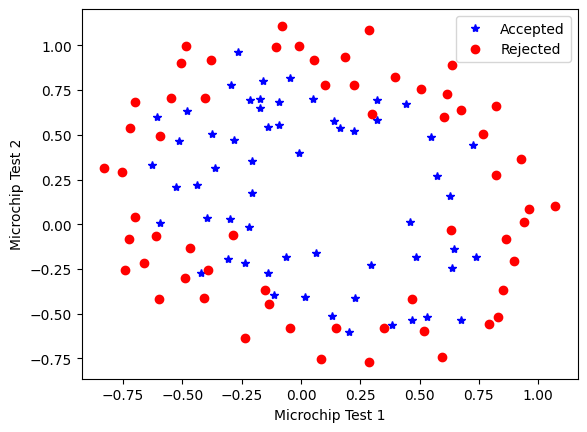

In [113]:
# Plot examples
plot_data(X_train, y_train[:], pos_label="Accepted", neg_label="Rejected")

# Set the y-axis label
plt.ylabel('Microchip Test 2')
# Set the x-axis label
plt.xlabel('Microchip Test 1')
plt.legend(loc="upper right")
plt.show()

Figure 3 shows that our dataset **cannot be separated into positive and negative examples by a straight-line through the plot**. Therefore, a straight forward application of logistic regression will not perform well on this dataset since logistic regression will only be able to find a linear decision boundary.


<a name="3.3"></a>
## 3.3 Feature mapping

One way to fit the data better is to create more features from each data point. In the provided function `map_feature`, we will map the features into all polynomial terms of $x_1$ and $x_2$ up to the sixth power.

$$\mathrm{map\_feature}(x) =
\left[\begin{array}{c}
x_1\\
x_2\\
x_1^2\\
x_1 x_2\\
x_2^2\\
x_1^3\\
\vdots\\
x_1 x_2^5\\
x_2^6\end{array}\right]$$

As a result of this mapping, our vector of two features (the scores on two QA tests) has been transformed into a 27-dimensional vector.

- A logistic regression classifier trained on this higher-dimension feature vector will have a more complex decision boundary and will be nonlinear when drawn in our 2-dimensional plot.
- The `map_feature` function is provided below:

In [114]:
def map_feature(X1, X2):
    """
    Feature mapping function to polynomial features
    """
    X1 = np.atleast_1d(X1)
    X2 = np.atleast_1d(X2)
    degree = 6
    out = []
    for i in range(1, degree+1):
        for j in range(i + 1):
            out.append((X1**(i-j) * (X2**j)))
    return np.stack(out, axis=1)

In [115]:
print("Original shape of data:", X_train.shape)

mapped_X =  map_feature(X_train[:, 0], X_train[:, 1])
print("Shape after feature mapping:", mapped_X.shape)

Original shape of data: (118, 2)
Shape after feature mapping: (118, 27)


Let's also print the first elements of `X_train` and `mapped_X` to see the tranformation.

In [116]:
print("X_train[0]:", X_train[0])
print("mapped X_train[0]:", mapped_X[0])

X_train[0]: [0.051267 0.69956 ]
mapped X_train[0]: [5.12670000e-02 6.99560000e-01 2.62830529e-03 3.58643425e-02
 4.89384194e-01 1.34745327e-04 1.83865725e-03 2.50892595e-02
 3.42353606e-01 6.90798869e-06 9.42624411e-05 1.28625106e-03
 1.75514423e-02 2.39496889e-01 3.54151856e-07 4.83255257e-06
 6.59422333e-05 8.99809795e-04 1.22782870e-02 1.67542444e-01
 1.81563032e-08 2.47750473e-07 3.38066048e-06 4.61305487e-05
 6.29470940e-04 8.58939846e-03 1.17205992e-01]


While the feature mapping allows us to build a more expressive classifier, it is also more susceptible to **overfitting**. In the next parts of the assignment, you will implement **regularized logistic regression** to fit the data and also see for yourself how regularization can help combat the overfitting problem.

<a name="3.4"></a>
## 3.4 Cost function for regularized logistic regression

In this part, you will implement the cost function for regularized logistic regression.

Recall that for regularized logistic regression, the cost function is of the form
$$J(\mathbf{w},b) = \frac{1}{m}  \sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$

Compare this to the cost function without regularization (which you implemented above), which is of the form

$$ J(\mathbf{w}.b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)\right]$$

The difference is the regularization term, which is $$\frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$
Note that the $b$ parameter is not regularized.

<a name='ex-05'></a>
### Exercise 5

Complete the `compute_cost_reg` function below to calculate the following term for each element in $w$
$$\frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$

The starter code then adds this to the cost without regularization (which you computed above in `compute_cost`) to calculate the cost with regulatization.

In [117]:
def compute_cost_reg(X, y, w, b, lambda_ = 1):
    m = X.shape[0]
    h = 1/(1+np.exp(-(X @ w + b)))
    base = -(1/m)*np.sum(y*np.log(h)+(1-y)*np.log(1-h))
    reg = (lambda_/(2*m))*np.sum(w**2)
    return base + reg

Run the cell below to check your implementation of the `compute_cost_reg` function.

In [118]:
X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 0.5
lambda_ = 0.5
cost = compute_cost_reg(X_mapped, y_train, initial_w, initial_b, lambda_)

print("Regularized cost :", cost)

# UNIT TEST
compute_cost_reg_test(compute_cost_reg)


Regularized cost : 0.6618252552483951
All tests passed!


**Expected Output**:
<table>
  <tr>
    <td> <b>Regularized cost : <b></td>
    <td> 0.6618252552483948 </td>
  </tr>
</table>

<a name="3.5"></a>
## 3.5 Gradient for regularized logistic regression

In this section, you will implement the gradient for regularized logistic regression.


The gradient of the regularized cost function has two components. The first, $\frac{\partial J(\mathbf{w},b)}{\partial b}$ is a scalar, the other is a vector with the same shape as the parameters $\mathbf{w}$, where the $j^\mathrm{th}$ element is defined as follows:

$$\frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m}  \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})  $$

$$\frac{\partial J(\mathbf{w},b)}{\partial w_j} = \left( \frac{1}{m}  \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) x_j^{(i)} \right) + \frac{\lambda}{m} w_j  \quad\, \mbox{for $j=0...(n-1)$}$$

Compare this to the gradient of the cost function without regularization (which you implemented above), which is of the form
$$
\frac{\partial J(\mathbf{w},b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})
$$
$$
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})x_{j}^{(i)}
$$


As you can see,$\frac{\partial J(\mathbf{w},b)}{\partial b}$ is the same, the difference is the following term in $\frac{\partial J(\mathbf{w},b)}{\partial w}$, which is $$\frac{\lambda}{m} w_j  \quad\, \mbox{for $j=0...(n-1)$}$$





<a name='ex-06'></a>
### Exercise 6

Complete the `compute_gradient_reg` function below to modify the code below to calculate the following term

$$\frac{\lambda}{m} w_j  \quad\, \mbox{for $j=0...(n-1)$}$$

The starter code will add this term to the $\frac{\partial J(\mathbf{w},b)}{\partial w}$ returned from `compute_gradient` above to get the gradient for the regularized cost function.

In [119]:
def compute_gradient_reg(X, y, w, b, lambda_ = 1):
    m, n = X.shape

    ## START CODE HERE ##

    dj_db, dj_dw = compute_gradient(X, y, w, b, lambda_)
    dj_dw += (lambda_ / m) * w

    ## END CODE HERE ##

    return dj_db, dj_dw

Run the cell below to check your implementation of the `compute_gradient_reg` function.

In [120]:
X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
np.random.seed(1)
initial_w  = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 0.5

lambda_ = 0.5
dj_db, dj_dw = compute_gradient_reg(X_mapped, y_train, initial_w, initial_b, lambda_)

print(f"dj_db: {dj_db}", )
print(f"First few elements of regularized dj_dw:\n {dj_dw[:4].tolist()}", )

# UNIT TESTS
compute_gradient_reg_test(compute_gradient_reg)

dj_db: 0.07138288792343654
First few elements of regularized dj_dw:
 [-0.010386028450548689, 0.011409852883280117, 0.0536273463274574, 0.003140278267313467]
All tests passed!


**Expected Output**:
<table>
  <tr>
    <td> <b>dj_db:</b>0.07138288792343656</td> </tr>
  <tr>
      <td> <b> First few elements of regularized dj_dw:</b> </td> </tr>
   <tr>
   <td> [-0.010386028450548701, 0.011409852883280116, 0.0536273463274574, 0.003140278267313463] </td>
  </tr>
</table>

<a name="3.6"></a>
## 3.6 Learning parameters using gradient descent

Similar to the previous parts, you will use your gradient descent function implemented above to learn the optimal parameters $w$,$b$.
- If you have completed the cost and gradient for regularized logistic regression correctly, you should be able to step through the next cell to learn the parameters $w$.
- After training our parameters, we will use it to plot the decision boundary.

**Note**

The code block below takes quite a while to run, especially with a non-vectorized version. You can reduce the `iterations` to test your implementation and iterate faster. If you have time, run for 100,000 iterations to see better results.

In [121]:
# Initialize fitting parameters
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1])-0.5
initial_b = 1.

# Set regularization parameter lambda_ to 1 (you can try varying this)
lambda_ = 0.01;
# Some gradient descent settings
iterations = 10000
alpha = 0.01

w,b, J_history,_ = gradient_descent(X_mapped, y_train, initial_w, initial_b,
                                    compute_cost_reg, compute_gradient_reg,
                                    alpha, iterations, lambda_)

Iteration    0: Cost     0.72   
Iteration 1000: Cost     0.59   
Iteration 2000: Cost     0.56   
Iteration 3000: Cost     0.53   
Iteration 4000: Cost     0.51   
Iteration 5000: Cost     0.50   
Iteration 6000: Cost     0.48   
Iteration 7000: Cost     0.47   
Iteration 8000: Cost     0.46   
Iteration 9000: Cost     0.45   
Iteration 9999: Cost     0.45   


<details>
<summary>
    <b>Expected Output: Cost < 0.5  (Click for details)</b>
</summary>

```
# Using the following settings
#np.random.seed(1)
#initial_w = np.random.rand(X_mapped.shape[1])-0.5
#initial_b = 1.
#lambda_ = 0.01;                                          
#iterations = 10000
#alpha = 0.01
Iteration    0: Cost     0.72   
Iteration 1000: Cost     0.59   
Iteration 2000: Cost     0.56   
Iteration 3000: Cost     0.53   
Iteration 4000: Cost     0.51   
Iteration 5000: Cost     0.50   
Iteration 6000: Cost     0.48   
Iteration 7000: Cost     0.47   
Iteration 8000: Cost     0.46   
Iteration 9000: Cost     0.45   
Iteration 9999: Cost     0.45       
    
```

<a name="3.7"></a>
## 3.7 Plotting the decision boundary
To help you visualize the model learned by this classifier, we will use our `plot_decision_boundary` function which plots the (non-linear) decision boundary that separates the positive and negative examples.

- In the function, we plotted the non-linear decision boundary by computing the classifier’s predictions on an evenly spaced grid and then drew a contour plot of where the predictions change from y = 0 to y = 1.

- After learning the parameters $w$,$b$, the next step is to plot a decision boundary.

ValueError: setting an array element with a sequence.

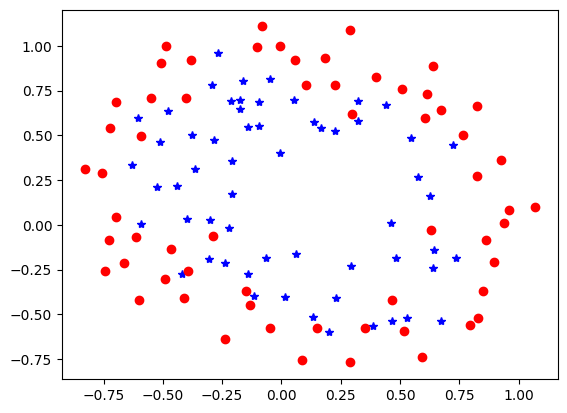

In [122]:
plot_decision_boundary(w, b, X_mapped, y_train)

<a name="3.8"></a>
## 3.8 Evaluating regularized logistic regression model

You will use the `predict` function that you implemented above to calculate the accuracy of the regulaized logistic regression model on the training set

In [ ]:
#Compute accuracy on the training set
p = predict(X_mapped, w, b)

print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

**Expected Output**:
<table>
  <tr>
    <td> <b>Train Accuracy:</b>~ 80%</td> </tr>
</table>

<a name="4"></a>
# 4 -  Logisitic regresion using Scikit-Learn

There is an open-source, commercially usable machine learning toolkit called [scikit-learn](https://scikit-learn.org/stable/index.html). This toolkit contains implementations of many of the algorithms that you will work with in this course.


**Step 1: Import Required Packages**

In [ ]:
from sklearn.linear_model import LogisticRegression

**Step 2: Create and fit the model**

The code below performs regression using scikit-learn. Scikit-learn has the [logisitc regression model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) which implements a closed-form linear regression.

<a name="ex07"></a>
### Exercise 7

Complete the code below to perform logistic regression using Scikit-Learn. Follow these steps:

1.   **Create a logistic regression object:** Use the appropriate class from Scikit-Learn to create a logistic regression object.
2.   **Fit the model:** Utilize the fit method associated with the  object to perform logistic regression using the first dataset.

In [ ]:
# load dataset
X_train, y_train = load_data("data/ex2data1.txt")

In [ ]:
pass

**Step 3: View Parameters**

The $\mathbf{w}$ and $\mathbf{b}$ parameters are referred to as 'coefficients' and 'intercept' in scikit-learn.

In [ ]:
b_sklearn = lr_model.intercept_
w_sklearn = lr_model.coef_
print(f"w = {w_sklearn}, b = {b_sklearn}")

**Expected Output**:
<table>
  <tr>
    <td> <b> w, b found by Scikit-Learn<b></td>
    <td>w = [[0.20535491 0.2005838 ]], b = [-25.05219314]</td>
  </tr>
</table>

In [ ]:
p = lr_model.predict(X_train)
print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

<a name="5"></a>
# 5 -  Softmax regression
In this assignment, you will implement a softmax regression model to classify flowers from the Iris dataset.

<a name="5.1"></a>
## 5.1 Problem Statement

The Iris dataset is a classic dataset in machine learning, consisting of 150 samples of iris flowers, each with 4 features (sepal length, sepal width, petal length, and petal width) and belonging to one of 3 species (setosa, versicolor, or virginica). Your goal is to build a model that can predict the species of an iris flower based on its features.

<a name="5.2"></a>
## 5.2 Loading and visualizing the data

You will start by loading the dataset for this task.
- The `load_dataset()` function shown below loads the data into variables `X_train` and `y_train`
  - `X_train` contains the features of the iris flowers:
       - Sepal length (in cm)
       - Sepal width (in cm)
       - Petal length (in cm)
       - Petal width (in cm)
  - `y_train` is the admission decision
      - y_train = [1,0,0] for setosa
      - y_train = [0,1,0] for versicolor
      - y_train = [0,0,1] for virginica
  - Both `X_train` and `y_train` are numpy arrays.


In [ ]:
def load_data():
    X = np.load("data/X_m.npy")
    y = np.load("data/y_m.npy")

    return X, y

# load dataset
X_train, y_train = load_data()

## **View the variables**
Let's get more familiar with your dataset.  
- A good place to start is to just print out each variable and see what it contains.

The code below prints the first five values of `X_train` and the type of the variable.

In [ ]:
print("Five elements in X_train are:\n", X_train[5:10])
print("Type of X_train:",type(X_train))

Now print the first five values of `y_train`

In [ ]:
print("Five elements in y_train are:\n", y_train[5:10])
print("Type of y_train:",type(y_train))

## **Check the dimensions of your variables**

Another useful way to get familiar with your data is to view its dimensions. Let's print the shape of `X_train` and `y_train` and see how many training examples we have in our dataset.

In [ ]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

## **Visualize your data**

Before starting to implement any learning algorithm, it is always good to visualize the data if possible. Visualization helps you understand the structure of the data and identify patterns or relationships between features.

The code below displays the data on a 2D plot, where the axes represent two features of the Iris dataset (e.g., sepal length and sepal width), and the different species are shown with different markers.

We use a helper function plot_data to generate this plot.

In [ ]:
def plot_data(X, y):
    """
    Plot the Iris dataset in 2D using two features.

    Args:
        X (numpy array): Features, shape (m, 4).
        y (numpy array): One-hot encoded labels, shape (m, 3).
    """
    # Convert one-hot encoded labels to class indices
    y_class = np.argmax(y, axis=1)

    # Define feature names
    feature_names = ["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]

    # Create a scatter plot for each pair of features
    plt.figure(figsize=(12, 6))

    # Plot sepal length vs sepal width
    plt.subplot(1, 2, 1)
    for species in range(3):
        plt.scatter(X[y_class == species, 0], X[y_class == species, 1], label=f"Species {species}")
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Sepal Length vs Sepal Width")
    plt.legend()

    # Plot petal length vs petal width
    plt.subplot(1, 2, 2)
    for species in range(3):
        plt.scatter(X[y_class == species, 2], X[y_class == species, 3], label=f"Species {species}")
    plt.xlabel(feature_names[2])
    plt.ylabel(feature_names[3])
    plt.title("Petal Length vs Petal Width")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
plot_data(X_train, y_train)

<a name='ex-08'></a>
### Exercise 8

In this exercise, you will visualize the Iris dataset by generating all possible 2D scatter plots for pairs of features. Your goal is to:

1. Generate scatter plots for all combinations of the four features.
2. Observe and analyze the relationships between the features for each species.

In [ ]:
pass

<a name="5.3"></a>
## 5.3  Softmax function
Recall that for softmax regression, the model is represented as:

$$ f_{\mathbf{w},b}(x) = g(\mathbf{w}\cdot \mathbf{x} + b)$$

where the function g is the softmax function. The softmax function is defined as:

$$g(z_i) = \frac{e^{z_i}}{\sum_{j=1}^Ke^{z_j}}$$

Here:

- $z_i$  is the i-th element of the input vector z.
- K is the total number of classes.

The denominator ensures that the output is a valid probability distribution (i.e., the probabilities sum to 1).

Let's implement the softmax function so it can be used by the rest of this assignment.

<a name='ex-09'></a>
### Exercise 9

Complete the softmax function to calculate:

$$g(z_i) = \frac{e^{z_i}}{\sum_{j=1}^Ke^{z_j}}$$


Requirements:

- The input z can be a single number, a 1D array, or a 2D array.

- If the input is an array, apply the softmax function to each row independently.

- Ensure numerical stability by subtracting the maximum value of
z before applying the exponential function.

In [ ]:
def softmax(z):
    z_shift = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

As mentioned before, your code should also work with vectors and matrices.

In [ ]:
print("softmax([ -1, 0, 1, 2]) = " + str(softmax(np.array([-1, 0, 1, 2]))))

z = np.array([
    [2.0, 1.0, 0.1],  # Sample 1
    [1.0, 2.0, 0.1],  # Sample 2
    [0.1, 1.0, 2.0]   # Sample 3
])

print("softmax(z) = " + str(softmax(z)))


**Expected Output**:
<table>
  <tr>
    <td><b>softmax([-1, 0, 1, 2])<b></td>
    <td>[0.0320586  0.08714432 0.23688282 0.64391426]</td>
  </tr>    
    <tr>
    <td><b>softmax(z)<b></td>
    <td>[[0.65900114 0.24243297 0.09856589]
 [0.24243297 0.65900114 0.09856589]
 [0.09856589 0.24243297 0.65900114]]</td>
  </tr>   
</table>

<a name="5.4"></a>
## 5.4 Cost function for softmax regression

In this section, you will implement the cost function for softmax regression.

<a name='ex-10'></a>
### Exercise 10

Complete the `compute_cost_softmax` function using the equations below.

Recall that for softmax regression, the cost function is of the form

$$ J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

where
* $m$ is the number of training examples in the dataset


* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point, which is -

    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (\sum_{k=1}^K-y_k^{(i)} \log\left(f_{\mathbf{w},b}^{(k)}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$
    
    
*  $f_{\mathbf{w},b}^{(k)}(\mathbf{x}^{(i)})$ is the model's prediction of the k-th class, while $y_k^{(i)}$ is 1 if the actual label is $k$.


Note:
* As you are doing this, remember that the variables `X_train` and `y_train` are not scalar values but matrices of shape ($m, n$) & ($𝑚, K$) respectively, where  $𝑛$ is the number of features, $𝑚$ is the number of training examples nd $K$ is the number of classes.
* You can use the sigmoid function that you implemented above for this part.

In [ ]:
def compute_cost_softmax(X, y, w, b):
    m = X.shape[0]
    logits = X @ w + b
    p = softmax(logits)
    cost = -(1/m)*np.sum(y*np.log(p))
    return cost

Run the cells below to check your implementation of the `compute_cost_softmax` function.

In [ ]:
m, n = X_train.shape
_, K= y_train.shape

# Compute and display cost with w initialized to zeroes
initial_w = np.zeros([n,K])
initial_b = np.zeros(K)
cost = compute_cost_softmax(X_train, y_train, initial_w, initial_b)
print('Cost at initial w (zeros): {:.3f}'.format(cost))

**Expected Output**:
<table>
  <tr>
    <td> <b>Cost at initial w (zeros)<b></td>
    <td> 1.099 </td>
  </tr>
</table>

<a name="5.5"></a>
## 5.5 Gradient for softmax regression

<a name='ex-11'></a>
### Exercise 11

Complete the `compute_gradient_softmax` function to compute $\frac{\partial J(\mathbf{w},b)}{\partial w}$, $\frac{\partial J(\mathbf{w},b)}{\partial b}$.


In [ ]:
def compute_gradient_softmax(X, y, w, b):
    m = X.shape[0]
    logits = X @ w + b
    p = softmax(logits)
    error = p - y
    dj_dw = (1/m)*(X.T @ error)
    dj_db = (1/m)*np.sum(error, axis=0)
    return dj_dw, dj_db

Run the cells below to check your implementation of the `compute_gradient_softmax` function.

In [ ]:
dj_db, dj_dw = compute_gradient_softmax(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w (zeros):{dj_db}' )
print(f'dj_dw at initial w (zeros):{dj_dw}')

**Expected Output**:
<table>
  <tr>
    <td> <b>dj_db at initial w and b(zeros)<b></td>
    <td> [-3.51570624e-16  1.76895535e-16 -4.14483263e-16] </td>
  </tr>
  <tr>
    <td> <b>dj_dw at initial w and b(zeros):<b></td>
    <td> [[ 0.27911111 -0.03088889 -0.24822222]
 [-0.12355556  0.09577778  0.02777778]
 [ 0.76533333 -0.16733333 -0.598     ]
 [ 0.31777778 -0.04222222 -0.27555556]] </td>
  </tr>
</table>

<a name="5.6"></a>
### 5.6 Learning parameters using gradient descent

Similar to the previous assignment, you will now find the optimal parameters of a softmax regression model by using gradient descent.
- You don't need to implement anything for this part. Simply run the cells below.

- A good way to verify that gradient descent is working correctly is to look
at the value of $J(\mathbf{w},b)$ and check that it is decreasing with each step.

- Assuming you have implemented the gradient and computed the cost correctly, your value of $J(\mathbf{w},b)$ should never increase, and should converge to a steady value by the end of the algorithm.

In [ ]:
def gradient_descent_softmax(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters):
    """
    Performs batch gradient descent to learn theta. Updates theta by taking
    num_iters gradient steps with learning rate alpha

    Args:
      X :    (array_like Shape (m, n)
      y :    (array_like Shape (m,))
      w_in : (array_like Shape (n,))  Initial values of parameters of the model
      b_in : (scalar)                 Initial value of parameter of the model
      cost_function:                  function to compute cost
      alpha : (float)                 Learning rate
      num_iters : (int)               number of iterations to run gradient descent

    Returns:
      w : (array_like Shape (n,)) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """

    # number of training examples
    m = len(X)

    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w_history = []

    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in)

        # Update Parameters using w, b, alpha and gradient
        w_in = w_in - alpha * dj_dw
        b_in = b_in - alpha * dj_db

        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion
            cost =  cost_function(X, y, w_in, b_in)
            J_history.append(cost)


        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")

    return w_in, b_in, J_history, w_history #return w and J,w history for graphing

Now let's run the gradient descent algorithm above to learn the parameters for our dataset.

In [ ]:
m, n = X_train.shape
_, K= y_train.shape

# Compute and display cost with w initialized to zeroes
initial_w = np.zeros([n,K])
initial_b = np.zeros(K)

# Some gradient descent settings
iterations = 10000
alpha = 0.01

w,b, J_history,_ = gradient_descent_softmax(X_train ,y_train, initial_w, initial_b,
                                   compute_cost_softmax, compute_gradient_softmax, alpha, iterations)

In [ ]:
plt.plot(J_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs. Iterations")
plt.show()

<a name="5.7"></a>
## 5.7 Evaluating softmax regression

We can evaluate the quality of the parameters we have found by seeing how well the learned model predicts on our training set.

You will implement the `predict_softmax` function below to do this.

<a name='ex-12'></a>
### Exercise 12

Complete the `predict_softmax` function to produce `[1, 0, 0]` or `[0,1,0]` or `[0,0,1]` predictions given a dataset and a learned parameters $w$ and $b$.

In [ ]:
def predict(X, w, b):
    probs = 1/(1+np.exp(-(X @ w + b)))
    return (probs >= 0.5).astype(int)

Once you have completed the function `predict_softmax`, let's run the code below to report the training accuracy of your classifier by computing the percentage of examples it got correct.

In [ ]:
#Compute accuracy on our training set
pred = predict_softmax(X_train, w,b)
y_true = np.argmax(y_train, axis=1)
y_pred = np.argmax(pred, axis=1)

# Compute accuracy
print('Train Accuracy: %f'%(np.mean(y_true == y_pred)*100))

<table>
  <tr>
    <td> <b>Train Accuracy (approx):<b></td>
    <td> 98.67 </td>
  </tr>
</table>